Используя шаблон ноутбука для распознавания видов одежды и аксессуаров из набора **fashion_mnist**, выполните следующие действия:

1. Создайте **9** моделей нейронной сети с различными архитектурами и сравните в них значения точности на проверочной выборке на последней эпохе и на тестовой выборке. Используйте следующее деление: обучающая выборка — **50000** примеров, проверочная выборка — **10000** примеров, тестовая выборка — **10000** примеров.

2. Создайте сравнительную таблицу в конце ноутбука, напишите выводы по результатам проведенных тестов.

Версия ниже переделана на **PyTorch**. Обучение и проверка моделей выполняются через `torch`.

In [1]:
# Библиотека для работы с массивами
import numpy as np

# Библиотека для работы с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Основные библиотеки PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Фиксируем случайность, чтобы результаты меньше менялись при повторном запуске
np.random.seed(42)
torch.manual_seed(42)

# Выбираем устройство: видеокарта, если она есть, иначе процессор
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Отрисовывать изображения в ноутбуке
%matplotlib inline

Устройство: cpu


In [2]:
class ModelsTorch:
  def __init__(self, epochs=10, batch_size=128, learning_rate=0.001):
    self.epochs = epochs
    self.batch_size = batch_size
    self.learning_rate = learning_rate

  def load_raw_data(self):
    # Сначала пробуем загрузить данные через torchvision.
    # Если в среде torchvision не работает, используем только загрузчик данных из keras.
    try:
      from torchvision import datasets

      train_data = datasets.FashionMNIST(
          root='./data',
          train=True,
          download=True
      )

      test_data = datasets.FashionMNIST(
          root='./data',
          train=False,
          download=True
      )

      x_train_full = train_data.data.numpy()
      y_train_full = train_data.targets.numpy()
      x_test = test_data.data.numpy()
      y_test = test_data.targets.numpy()

    except Exception as error:
      print('torchvision не загрузился, поэтому используется keras только для загрузки набора данных.')
      print('Причина:', error)

      from keras.datasets import fashion_mnist
      (x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

    return x_train_full, y_train_full, x_test, y_test

  def load_data(self):
    # Загрузка исходных данных
    x_train_full, y_train_full, x_test, y_test = self.load_raw_data()

    # Преобразование изображения 28x28 в вектор из 784 чисел
    x_train_full = x_train_full.reshape(60000, 784).astype('float32') / 255.0
    x_test = x_test.reshape(10000, 784).astype('float32') / 255.0

    # Деление выборки: 50000 обучение, 10000 проверка, 10000 тест
    x_train = x_train_full[:50000]
    y_train = y_train_full[:50000]

    x_val = x_train_full[50000:]
    y_val = y_train_full[50000:]

    # В PyTorch для CrossEntropyLoss ответы должны быть числами классов, а не one-hot
    x_train = torch.tensor(x_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)

    x_val = torch.tensor(x_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)

    x_test = torch.tensor(x_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    # Создание наборов данных
    train_dataset = TensorDataset(x_train, y_train)
    val_dataset = TensorDataset(x_val, y_val)
    test_dataset = TensorDataset(x_test, y_test)

    # Загрузчики данных
    train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

  def create_model(self, neurons):
    # Простая полносвязная модель: вход 784, скрытый слой, выход 10 классов
    model = nn.Sequential(
        nn.Linear(784, neurons),
        nn.ReLU(),
        nn.Linear(neurons, 10)
    )

    return model.to(device)

  def train_one_epoch(self, model, train_loader, criterion, optimizer):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      # Прямой проход
      outputs = model(x_batch)
      loss = criterion(outputs, y_batch)

      # Обратный проход
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # Подсчет ошибки и точности
      batch_size = y_batch.size(0)
      total_loss += loss.item() * batch_size

      _, predicted = torch.max(outputs, 1)
      correct += (predicted == y_batch).sum().item()
      total += batch_size

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

  def evaluate(self, model, data_loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    # Отключаем расчет градиентов при проверке
    with torch.no_grad():
      for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += batch_size

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

  def results(self):
    train_loader, val_loader, test_loader = self.load_data()

    neuron_types = [32, 64, 128, 256, 512, 1024, 70, 150, 700]
    results = []
    history = {}

    criterion = nn.CrossEntropyLoss()

    for neurons in neuron_types:
      print()
      print('Количество нейронов в обучении:', neurons)

      model = self.create_model(neurons)
      optimizer = torch.optim.Adam(model.parameters(), lr=self.learning_rate)

      history[neurons] = {
          'accuracy': [],
          'val_accuracy': [],
          'loss': [],
          'val_loss': []
      }

      for epoch in range(self.epochs):
        train_loss, train_accuracy = self.train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_accuracy = self.evaluate(model, val_loader, criterion)

        history[neurons]['accuracy'].append(train_accuracy)
        history[neurons]['val_accuracy'].append(val_accuracy)
        history[neurons]['loss'].append(train_loss)
        history[neurons]['val_loss'].append(val_loss)

        print(
            f'Эпоха {epoch + 1}/{self.epochs} | '
            f'accuracy: {train_accuracy:.4f} | '
            f'loss: {train_loss:.4f} | '
            f'val_accuracy: {val_accuracy:.4f} | '
            f'val_loss: {val_loss:.4f}'
        )

      # Проверка качества на тестовой выборке
      loss_test, accuracy_test = self.evaluate(model, test_loader, criterion)

      results.append({
          'Нейроны': neurons,
          'Точность на обучающей выборке': history[neurons]['accuracy'][-1],
          'Точность на тестовой выборке': accuracy_test,
          'Точность на валидационной выборке': history[neurons]['val_accuracy'][-1],
          'Ошибка на обучающей выборке': history[neurons]['loss'][-1],
          'Ошибка на тестовой выборке': loss_test,
          'Ошибка на валидационной выборке': history[neurons]['val_loss'][-1]
      })

    df = pd.DataFrame(results)

    return df, history

In [3]:
m1 = ModelsTorch(epochs=10, batch_size=128)
df, history = m1.results()

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.27MB/s]



Количество нейронов в обучении: 32
Эпоха 1/10 | accuracy: 0.7504 | loss: 0.7372 | val_accuracy: 0.8122 | val_loss: 0.5385
Эпоха 2/10 | accuracy: 0.8330 | loss: 0.4887 | val_accuracy: 0.8346 | val_loss: 0.4780
Эпоха 3/10 | accuracy: 0.8450 | loss: 0.4463 | val_accuracy: 0.8443 | val_loss: 0.4477
Эпоха 4/10 | accuracy: 0.8523 | loss: 0.4210 | val_accuracy: 0.8537 | val_loss: 0.4249
Эпоха 5/10 | accuracy: 0.8582 | loss: 0.4064 | val_accuracy: 0.8561 | val_loss: 0.4143
Эпоха 6/10 | accuracy: 0.8648 | loss: 0.3896 | val_accuracy: 0.8602 | val_loss: 0.4050
Эпоха 7/10 | accuracy: 0.8667 | loss: 0.3797 | val_accuracy: 0.8621 | val_loss: 0.3928
Эпоха 8/10 | accuracy: 0.8694 | loss: 0.3705 | val_accuracy: 0.8616 | val_loss: 0.3894
Эпоха 9/10 | accuracy: 0.8721 | loss: 0.3611 | val_accuracy: 0.8634 | val_loss: 0.3849
Эпоха 10/10 | accuracy: 0.8741 | loss: 0.3524 | val_accuracy: 0.8638 | val_loss: 0.3833

Количество нейронов в обучении: 64
Эпоха 1/10 | accuracy: 0.7694 | loss: 0.6830 | val_accura

In [4]:
# Вывод итоговой таблицы
display(df)

# Определение лучшей модели по точности на тестовой выборке
best_model_row = df.loc[df['Точность на тестовой выборке'].idxmax()]

print('Лучшая модель:')
print(best_model_row)

,Нейроны,Точность на обучающей выборке,Точность на тестовой выборке,Точность на валидационной выборке,Ошибка на обучающей выборке,Ошибка на тестовой выборке,Ошибка на валидационной выборке
0,32,0.87406,0.8565,0.8638,0.352446,0.406113,0.383296
1,64,0.88432,0.8642,0.8739,0.325712,0.380890,0.360112
2,128,0.89694,0.8722,0.8807,0.284451,0.362723,0.339174
3,256,0.90770,0.8783,0.8864,0.253558,0.343330,0.321378
4,512,0.91322,0.8830,0.8877,0.237374,0.331838,0.309032
5,1024,0.91554,0.8808,0.8901,0.226287,0.334344,0.311567
6,70,0.89030,0.8682,0.8747,0.307627,0.375572,0.353958
7,150,0.90046,0.8755,0.8780,0.273746,0.352059,0.331765
8,700,0.91494,0.8855,0.8926,0.230193,0.329817,0.301785


Лучшая модель:
Нейроны                              700.000000
Точность на обучающей выборке          0.914940
Точность на тестовой выборке           0.885500
Точность на валидационной выборке      0.892600
Ошибка на обучающей выборке            0.230193
Ошибка на тестовой выборке             0.329817
Ошибка на валидационной выборке        0.301785
Name: 8, dtype: float64


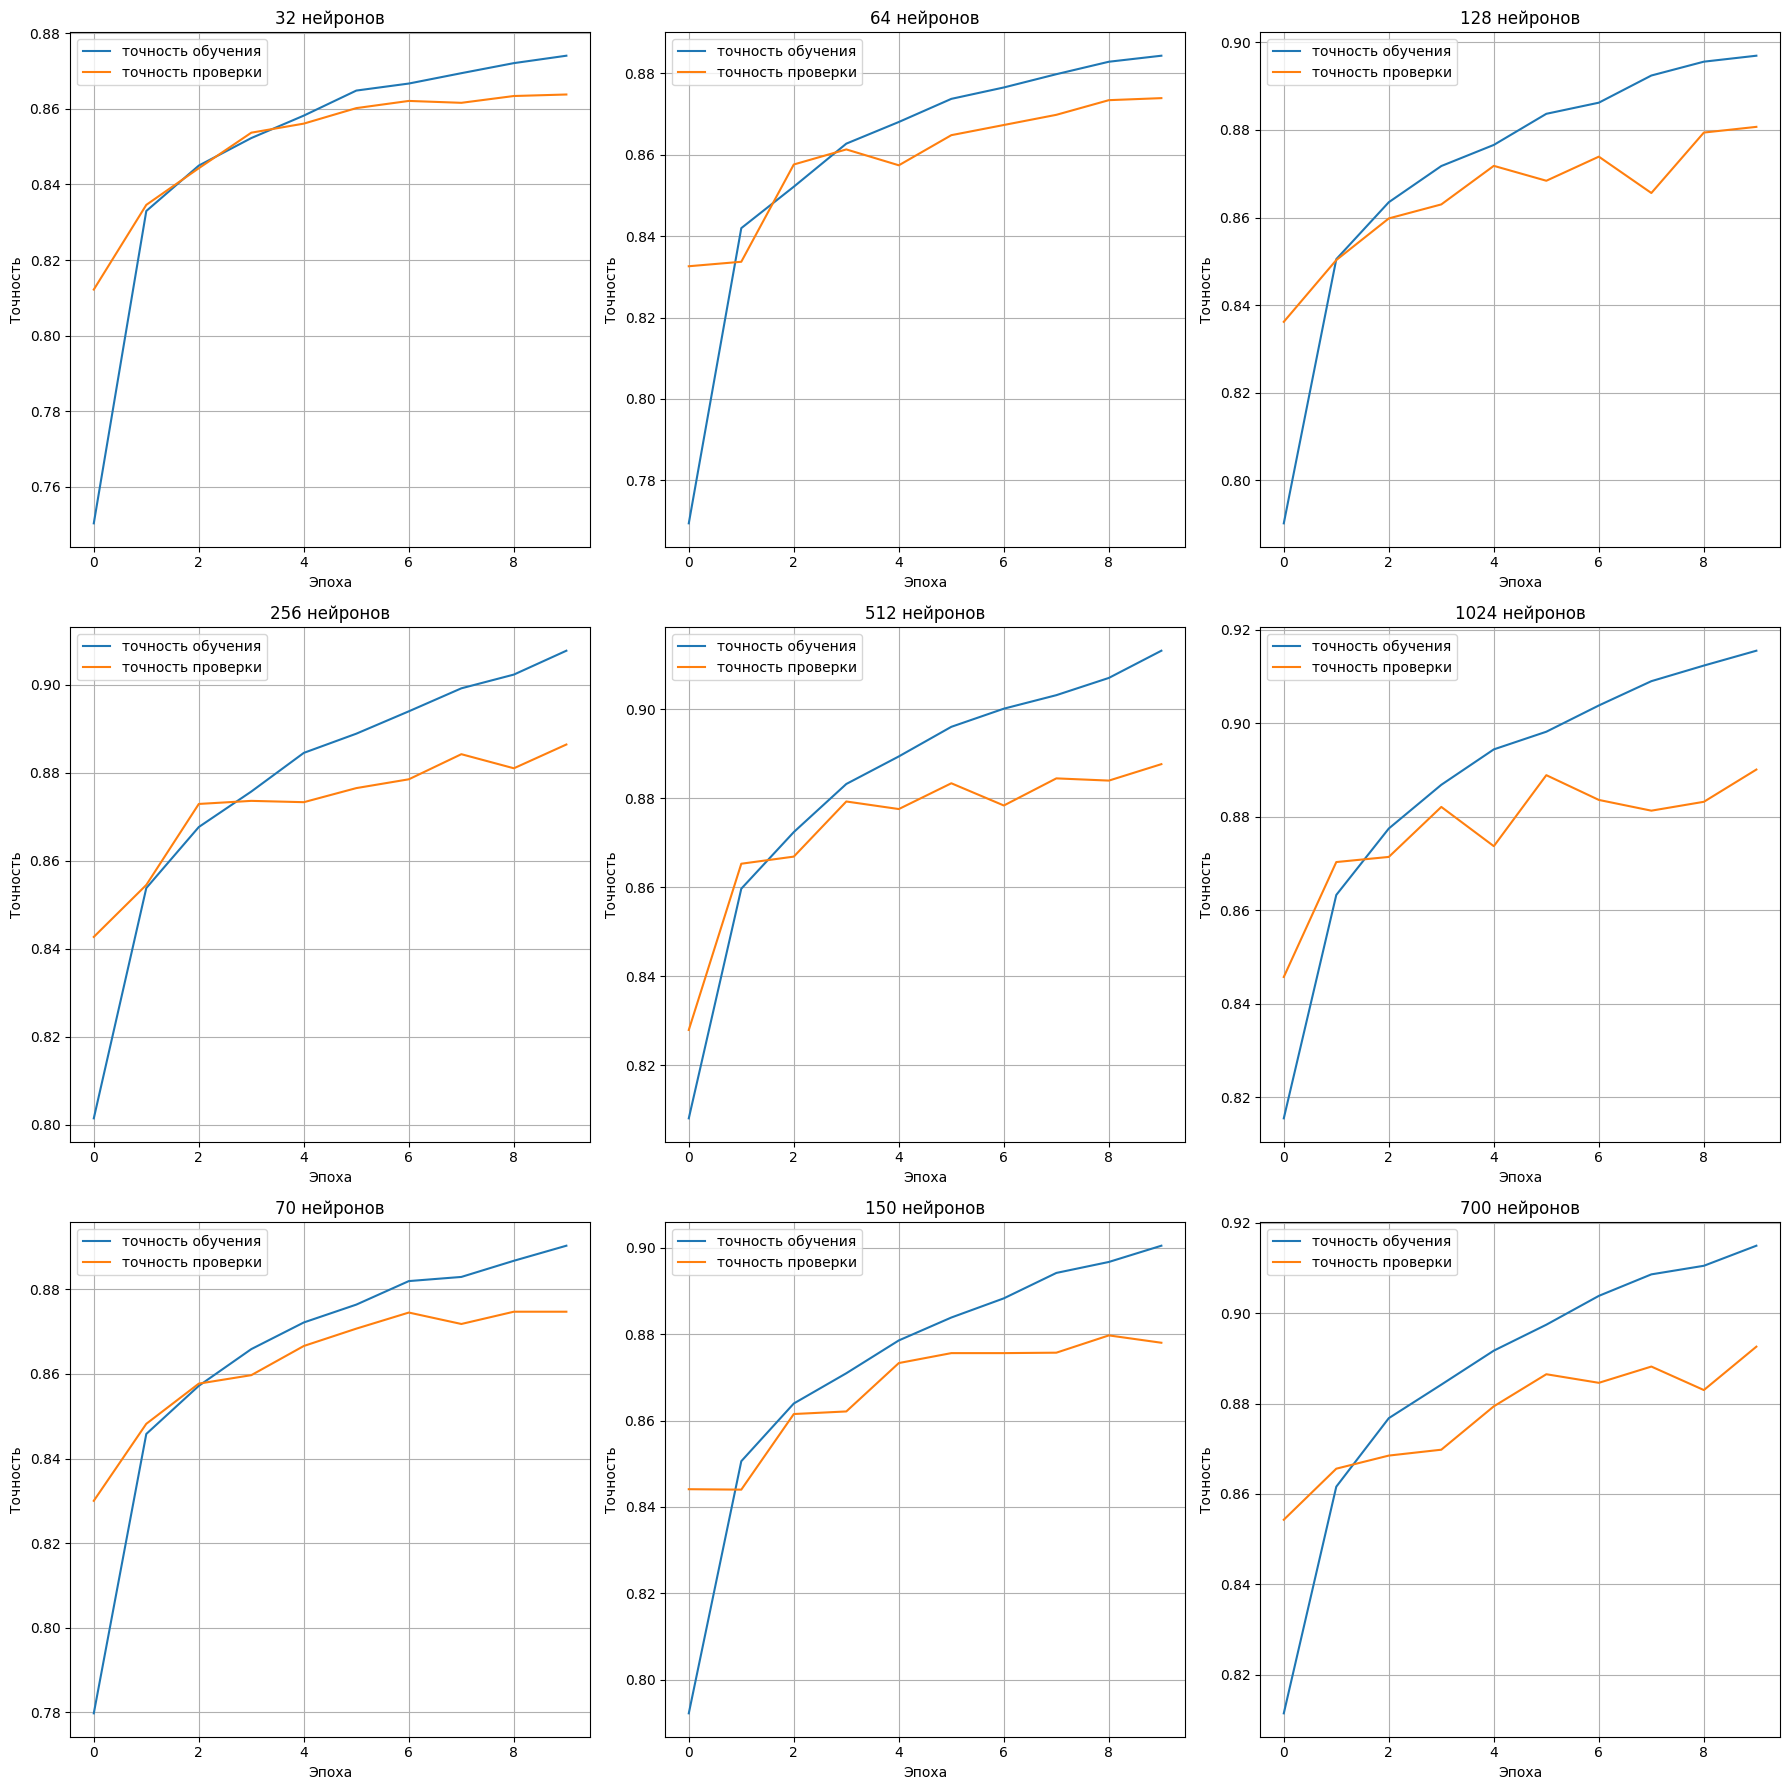

In [5]:
# Графики точности для всех 9 моделей
neuron_types = [32, 64, 128, 256, 512, 1024, 70, 150, 700]

fig, axs = plt.subplots(3, 3, figsize=(18, 18))

for i, neurons in enumerate(neuron_types):
  row = i // 3
  col = i % 3

  axs[row, col].set_title(f'{neurons} нейронов')
  axs[row, col].plot(history[neurons]['accuracy'], label='точность обучения')
  axs[row, col].plot(history[neurons]['val_accuracy'], label='точность проверки')
  axs[row, col].set_xlabel('Эпоха')
  axs[row, col].set_ylabel('Точность')
  axs[row, col].legend()
  axs[row, col].grid(True)

plt.tight_layout()
plt.show()

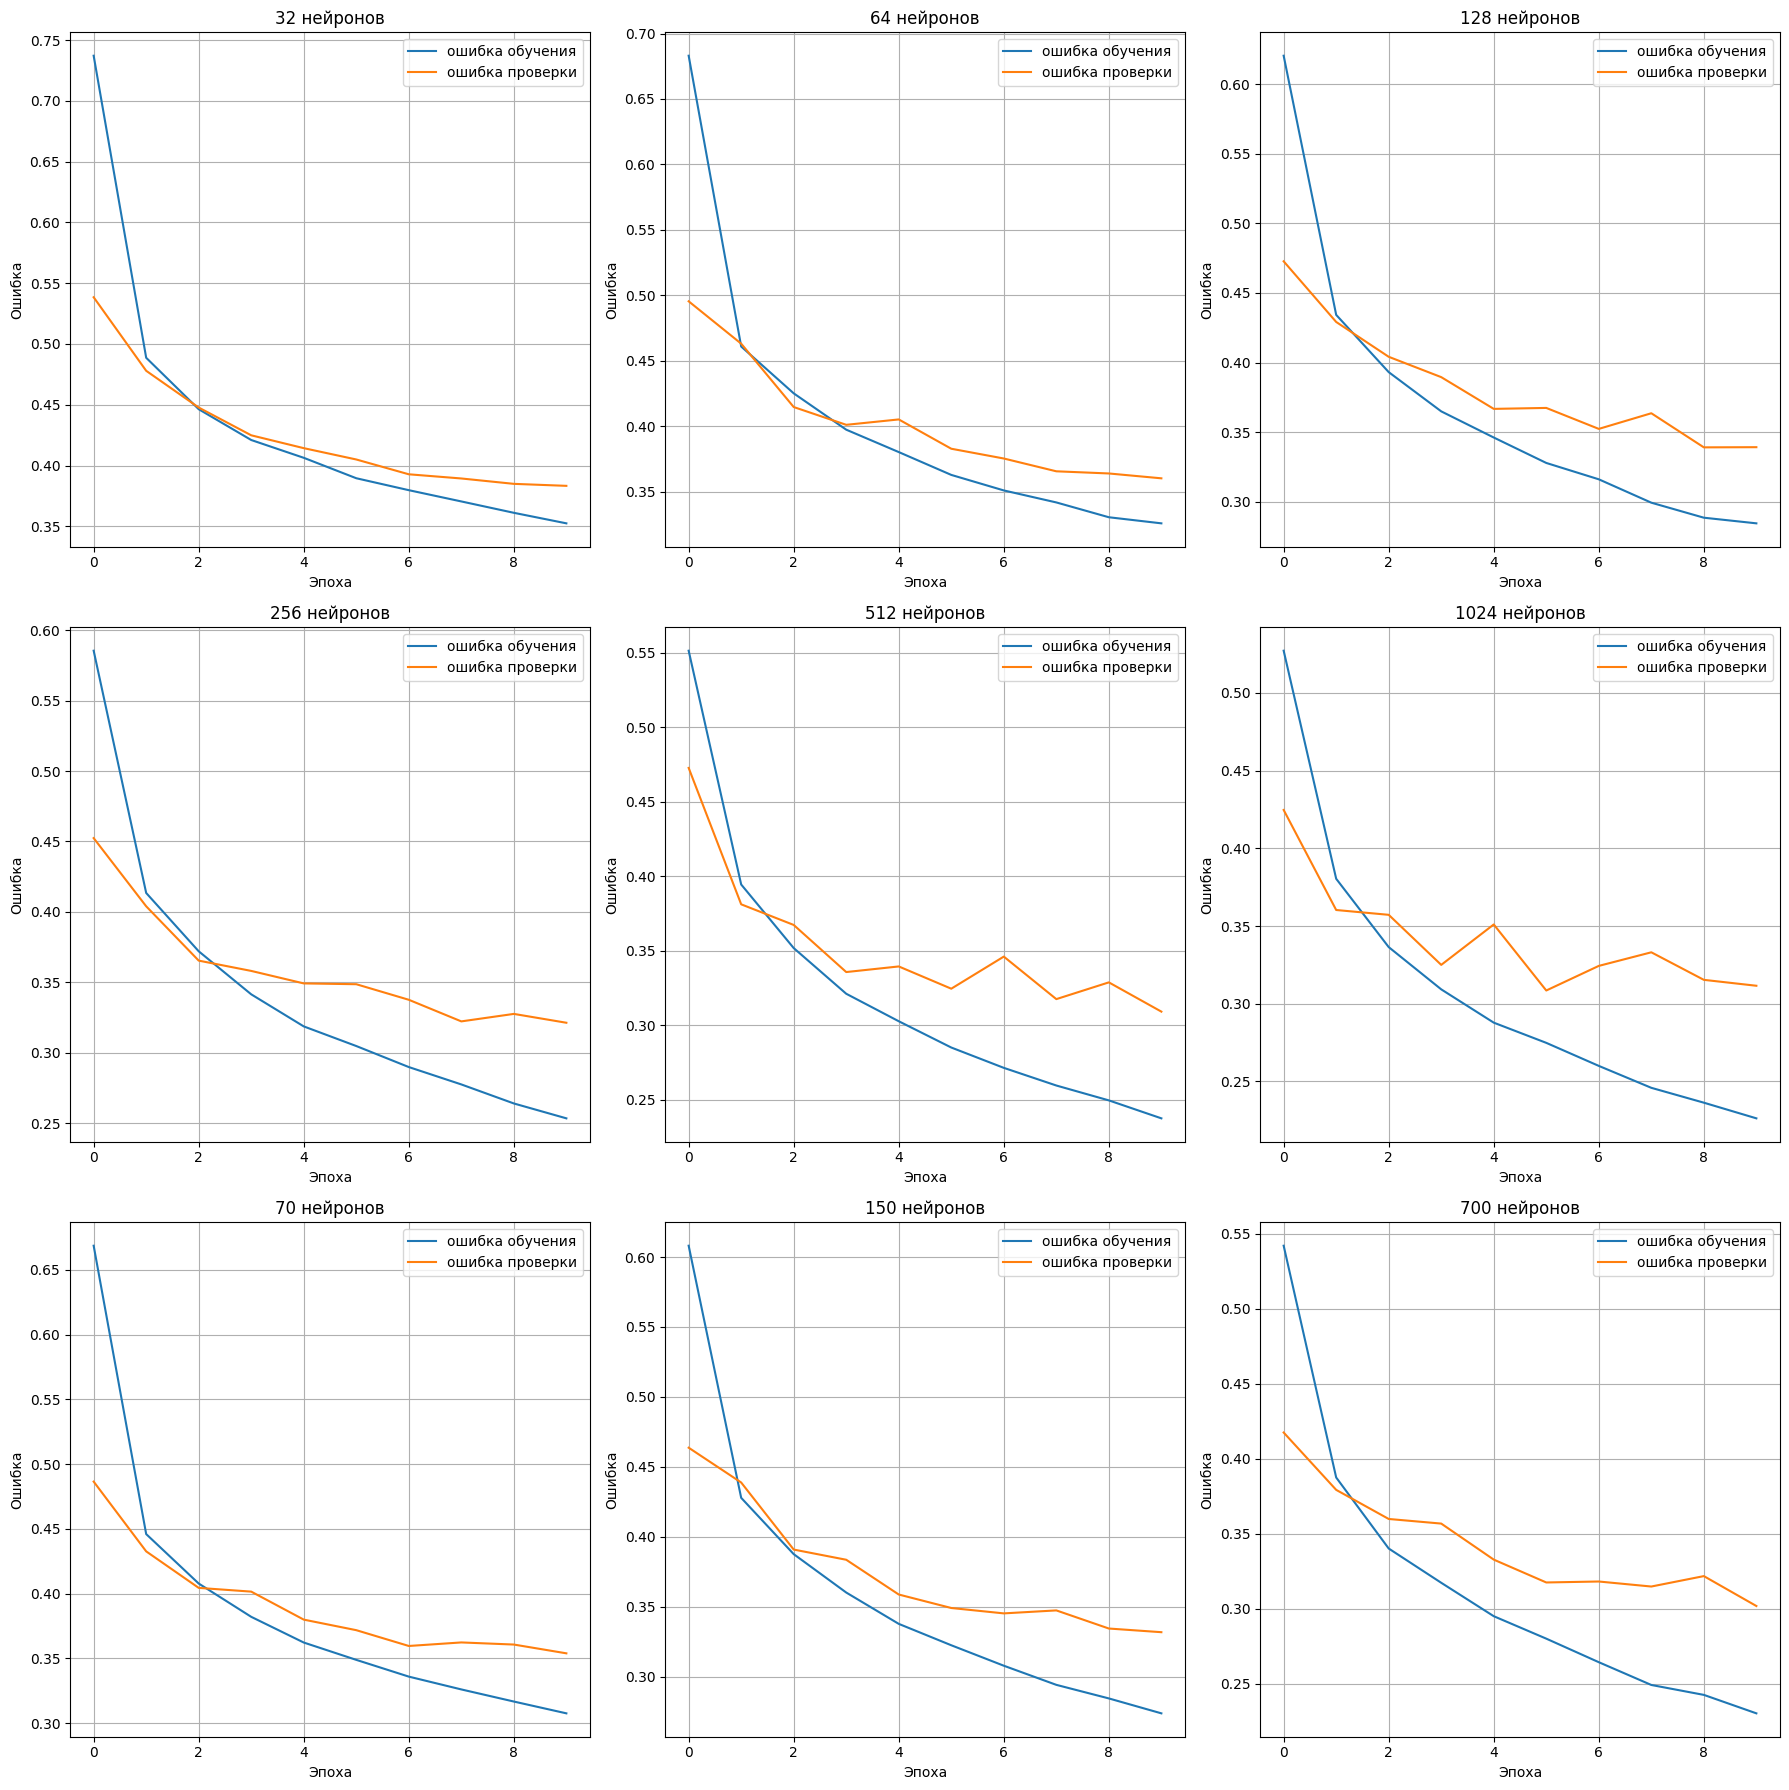

In [6]:
# Графики ошибки для всех 9 моделей
neuron_types = [32, 64, 128, 256, 512, 1024, 70, 150, 700]

fig, axs = plt.subplots(3, 3, figsize=(18, 18))

for i, neurons in enumerate(neuron_types):
  row = i // 3
  col = i % 3

  axs[row, col].set_title(f'{neurons} нейронов')
  axs[row, col].plot(history[neurons]['loss'], label='ошибка обучения')
  axs[row, col].plot(history[neurons]['val_loss'], label='ошибка проверки')
  axs[row, col].set_xlabel('Эпоха')
  axs[row, col].set_ylabel('Ошибка')
  axs[row, col].legend()
  axs[row, col].grid(True)

plt.tight_layout()
plt.show()